# Deception & Error Analysis — v2 (Memory-Fixed Experiment)

## Overview
Comparative deception and error analysis between v1 (broken cross-game memory) and v2 (fixed model-centric memory). This notebook examines:

1. **Deception patterns** — How does working memory affect deceptive behaviour?
2. **Error & Reliability** — Operational failures across models
3. **v1 vs v2 comparison** — Does correct memory change deception/honesty?

### Prerequisites
Run the deception analyzer on v2:
```bash
python deception_analyzer.py results/3game_experiment_v2/ --model "openrouter:x-ai/grok-4.1-fast"
```

In [1]:
import pandas as pd
import json
import re
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_theme(style="whitegrid")

# Paths for both experiments
base_v1 = os.path.join(os.path.dirname(os.getcwd()), "results", "3game_experiment")
base_v2 = os.path.join(os.path.dirname(os.getcwd()), "results", "3game_experiment_v2")
games = ["game1", "game2", "game3"]

def strip_model_prefix(model_id: str) -> str:
    """Strip provider prefix: 'openrouter:x-ai/grok-4.1-fast' -> 'x-ai/grok-4.1-fast'"""
    _, sep, rest = model_id.partition(":")
    return rest if sep else model_id

def load_experiment(base_path, label):
    """Load all data for one experiment."""
    # Game data
    game_data_all = {}
    game_id_to_name = {}
    for game in games:
        path = os.path.join(base_path, game, "lmvsgame.json")
        if os.path.exists(path):
            with open(path, "r") as f:
                gdata = json.load(f)
            game_data_all[game] = gdata
            raw_id = gdata.get("id")
            if raw_id:
                game_id_to_name[str(raw_id)] = game

    # Experiment summary
    summary_path = os.path.join(base_path, "experiment_summary.json")
    with open(summary_path, "r") as f:
        summary_data = json.load(f)

    # Model mapping
    model_mapping = []
    for game_name, game_info in summary_data["results"].items():
        if "power_model_map" in game_info:
            for power, model in game_info["power_model_map"].items():
                model_mapping.append({
                    "game": game_name, "power": power,
                    "model_name": strip_model_prefix(model)
                })
    model_df = pd.DataFrame(model_mapping)

    # Supply center outcomes
    sc_data = []
    for game_name, game_info in summary_data["results"].items():
        if "supply_centers" in game_info:
            for power, sc_info in game_info["supply_centers"].items():
                sc_data.append({"game": game_name, "power": power,
                                "final_sc": sc_info["count"],
                                "eliminated": sc_info.get("eliminated", False)})
    sc_df = pd.DataFrame(sc_data)

    # LLM responses
    all_responses = []
    for game in games:
        csv_path = os.path.join(base_path, game, "llm_responses.csv")
        if os.path.exists(csv_path):
            df = pd.read_csv(csv_path)
            df["game"] = game
            all_responses.append(df)
    resp_df = pd.concat(all_responses, ignore_index=True) if all_responses else pd.DataFrame()

    # Deception scores
    deception_csv = os.path.join(base_path, "deception_scores.csv")
    has_deception = os.path.exists(deception_csv)
    if has_deception:
        dec_df = pd.read_csv(deception_csv)
        dec_df["game"] = dec_df["game_id"].map(game_id_to_name)
        dec_df = dec_df.dropna(subset=["game"])
    else:
        dec_df = pd.DataFrame()

    return {
        "label": label,
        "game_data": game_data_all,
        "game_id_to_name": game_id_to_name,
        "summary": summary_data,
        "model_df": model_df,
        "sc_df": sc_df,
        "resp_df": resp_df,
        "dec_df": dec_df,
        "has_deception": has_deception,
    }

v1 = load_experiment(base_v1, "v1 (broken memory)")
v2 = load_experiment(base_v2, "v2 (fixed memory)")

print(f"v1: {len(v1['resp_df'])} LLM responses, deception={'YES' if v1['has_deception'] else 'NO'}")
print(f"v2: {len(v2['resp_df'])} LLM responses, deception={'YES' if v2['has_deception'] else 'NO'}")
if not v2['has_deception']:
    print("\nWARNING: v2 deception_scores.csv not found. Run deception_analyzer.py first.")
    print("Deception comparison sections will show v1 only. Error analysis works for both.")

v1: 2584 LLM responses, deception=YES
v2: 2325 LLM responses, deception=YES


---
# Part 1: Deception Analysis

The deception analyzer compares each power's **private diary**, **public messages**, and **actual orders** to produce a deception score (0.0 = fully honest, 1.0 = fully deceptive).

## 1.1 Deception Score Distribution (v1 vs v2)

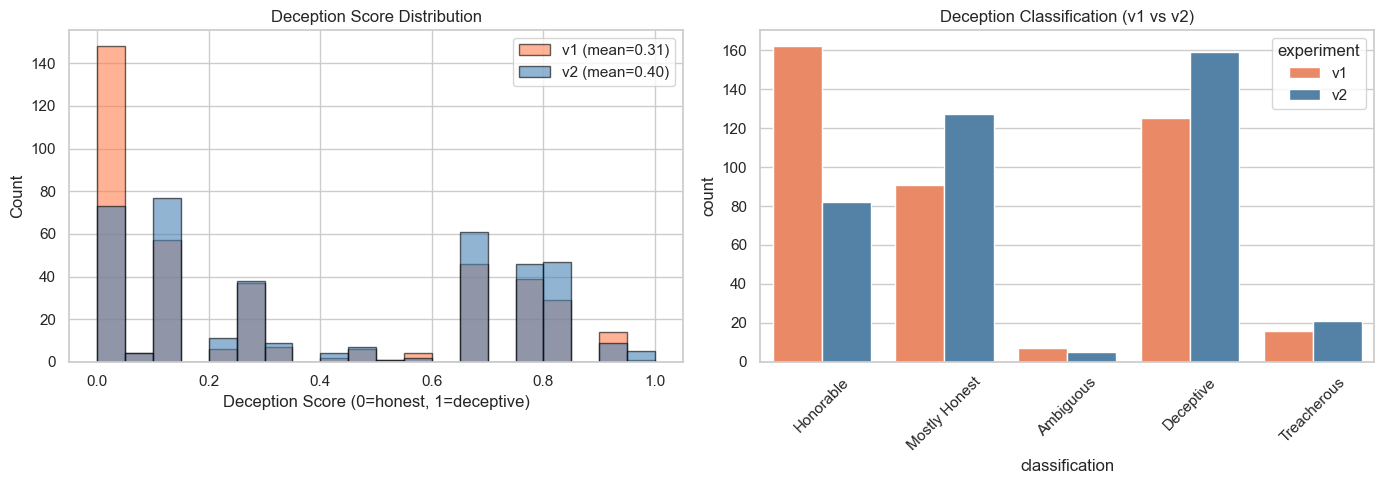


v1: 401 records | mean=0.311 | median=0.150 | std=0.334

v2: 394 records | mean=0.403 | median=0.275 | std=0.328


In [2]:
def get_valid_deception(exp):
    if not exp['has_deception']:
        return pd.DataFrame()
    return exp['dec_df'][exp['dec_df']['deception_score'] >= 0].copy()

v1_dec = get_valid_deception(v1)
v2_dec = get_valid_deception(v2)

has_both = len(v1_dec) > 0 and len(v2_dec) > 0
has_any = len(v1_dec) > 0 or len(v2_dec) > 0

if has_any:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Side-by-side histograms
    if len(v1_dec) > 0:
        axes[0].hist(v1_dec["deception_score"], bins=20, alpha=0.6, color="coral",
                     edgecolor="black", label=f"v1 (mean={v1_dec['deception_score'].mean():.2f})")
    if len(v2_dec) > 0:
        axes[0].hist(v2_dec["deception_score"], bins=20, alpha=0.6, color="steelblue",
                     edgecolor="black", label=f"v2 (mean={v2_dec['deception_score'].mean():.2f})")
    axes[0].set_xlabel("Deception Score (0=honest, 1=deceptive)")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Deception Score Distribution")
    axes[0].legend()

    # Classification comparison
    class_order = ["Honorable", "Mostly Honest", "Ambiguous", "Deceptive", "Treacherous"]
    class_data = []
    if len(v1_dec) > 0:
        for cls in class_order:
            class_data.append({"classification": cls, "experiment": "v1",
                               "count": (v1_dec["classification"] == cls).sum()})
    if len(v2_dec) > 0:
        for cls in class_order:
            class_data.append({"classification": cls, "experiment": "v2",
                               "count": (v2_dec["classification"] == cls).sum()})
    class_df = pd.DataFrame(class_data)
    sns.barplot(data=class_df, x="classification", y="count", hue="experiment",
               ax=axes[1], palette={"v1": "coral", "v2": "steelblue"})
    axes[1].set_title("Deception Classification (v1 vs v2)")
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

    # Summary stats
    for label, dec in [("v1", v1_dec), ("v2", v2_dec)]:
        if len(dec) > 0:
            print(f"\n{label}: {len(dec)} records | mean={dec['deception_score'].mean():.3f} | "
                  f"median={dec['deception_score'].median():.3f} | std={dec['deception_score'].std():.3f}")
else:
    print("No deception data available for either experiment.")

## 1.2 Deception by LLM Model (v1 vs v2)
Does correct memory make models more or less deceptive? With working memory, models know who betrayed them — this could increase strategic deception or promote honesty with trusted allies.

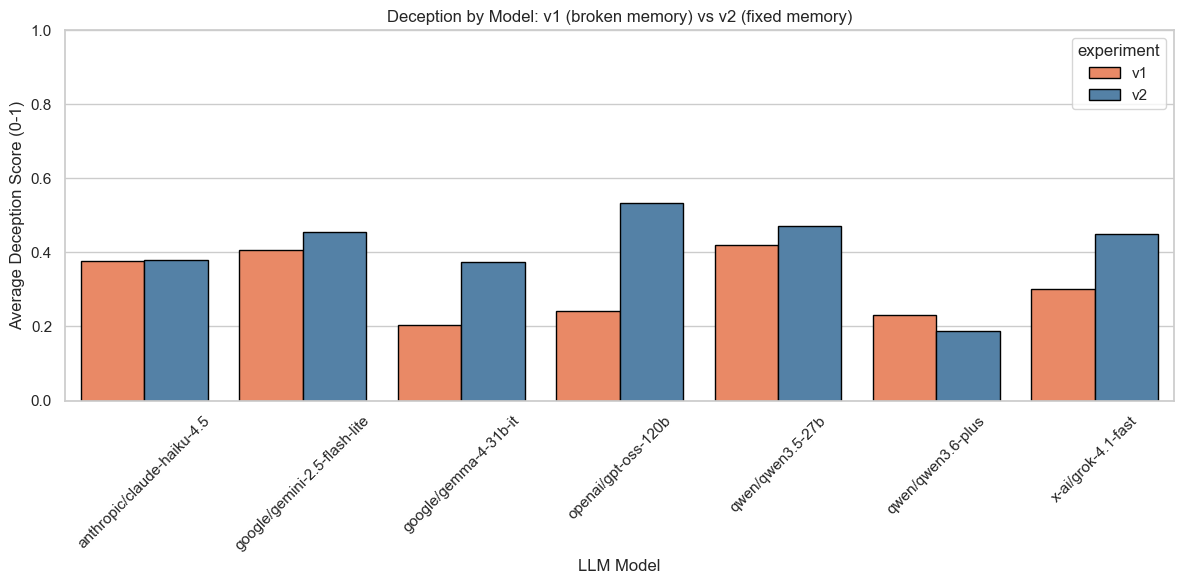


Deception score change (v2 - v1):
experiment                      v1    v2  delta
model_name                                     
qwen/qwen3.6-plus            0.231 0.188 -0.042
anthropic/claude-haiku-4.5   0.376 0.380  0.005
google/gemini-2.5-flash-lite 0.406 0.455  0.049
qwen/qwen3.5-27b             0.419 0.473  0.053
x-ai/grok-4.1-fast           0.301 0.449  0.148
google/gemma-4-31b-it        0.205 0.373  0.169
openai/gpt-oss-120b          0.242 0.534  0.292

Positive delta = MORE deceptive in v2 (with memory)
Negative delta = LESS deceptive in v2 (with memory)


In [3]:
if has_any:
    model_dec_data = []
    for label, dec, exp in [("v1", v1_dec, v1), ("v2", v2_dec, v2)]:
        if len(dec) == 0:
            continue
        merged = pd.merge(dec, exp['model_df'], on=["game", "power"], how="inner")
        grouped = merged.groupby("model_name")["deception_score"].agg(["mean", "std", "count"]).reset_index()
        grouped["experiment"] = label
        model_dec_data.append(grouped)

    if model_dec_data:
        model_dec_combined = pd.concat(model_dec_data, ignore_index=True)

        fig, ax = plt.subplots(figsize=(12, 6))
        sns.barplot(data=model_dec_combined, x="model_name", y="mean", hue="experiment",
                    palette={"v1": "coral", "v2": "steelblue"}, ax=ax, edgecolor="black")
        ax.set_xlabel("LLM Model")
        ax.set_ylabel("Average Deception Score (0-1)")
        ax.set_title("Deception by Model: v1 (broken memory) vs v2 (fixed memory)")
        ax.set_ylim(0, 1)
        ax.tick_params(axis="x", rotation=45)
        plt.tight_layout()
        plt.show()

        # Print table
        pivot = model_dec_combined.pivot(index="model_name", columns="experiment", values="mean")
        if "v1" in pivot.columns and "v2" in pivot.columns:
            pivot["delta"] = pivot["v2"] - pivot["v1"]
            pivot = pivot.sort_values("delta")
            print("\nDeception score change (v2 - v1):")
            print(pivot.to_string(float_format="{:.3f}".format))
            print(f"\nPositive delta = MORE deceptive in v2 (with memory)")
            print(f"Negative delta = LESS deceptive in v2 (with memory)")
else:
    print("No deception data available.")

## 1.3 Deception Over Time (v1 vs v2)
Does deception evolve differently when models have correct memory of past betrayals?

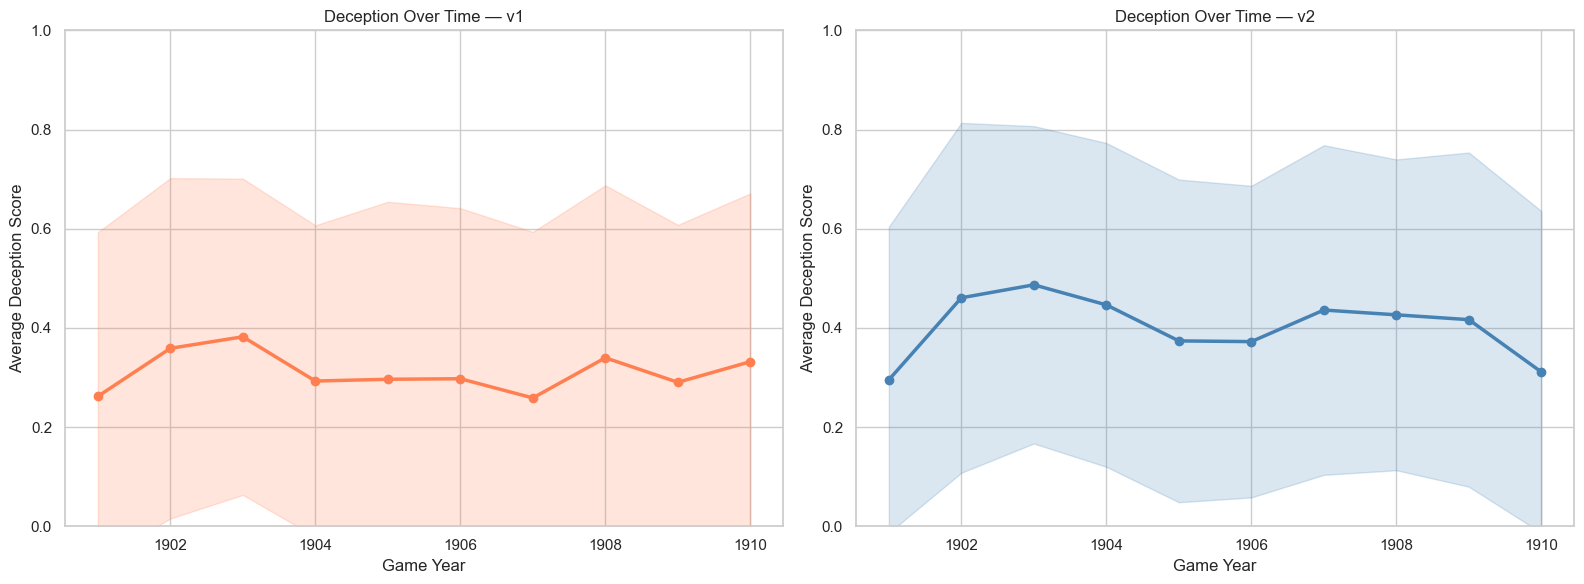

In [4]:
if has_any:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for label, dec, ax, color in [("v1", v1_dec, axes[0], "coral"), ("v2", v2_dec, axes[1], "steelblue")]:
        if len(dec) == 0:
            ax.set_title(f"{label}: No data")
            continue
        dec = dec.copy()
        dec["year"] = dec["phase"].str.extract(r"(19\d{2})").astype(float)
        year_avg = dec.groupby("year")["deception_score"].agg(["mean", "std"]).reset_index()

        ax.fill_between(year_avg["year"], year_avg["mean"] - year_avg["std"],
                        year_avg["mean"] + year_avg["std"], alpha=0.2, color=color)
        ax.plot(year_avg["year"], year_avg["mean"], marker="o", color=color, linewidth=2.5)
        ax.set_xlabel("Game Year")
        ax.set_ylabel("Average Deception Score")
        ax.set_title(f"Deception Over Time — {label}")
        ax.set_ylim(0, 1)

    plt.tight_layout()
    plt.show()
else:
    print("No deception data available.")

## 1.4 Deception Across Games (Does Memory Change Behavior in Games 2-3?)
Key question: In v2, games 2 and 3 have working memory. Do models become more or less deceptive as they accumulate experience?

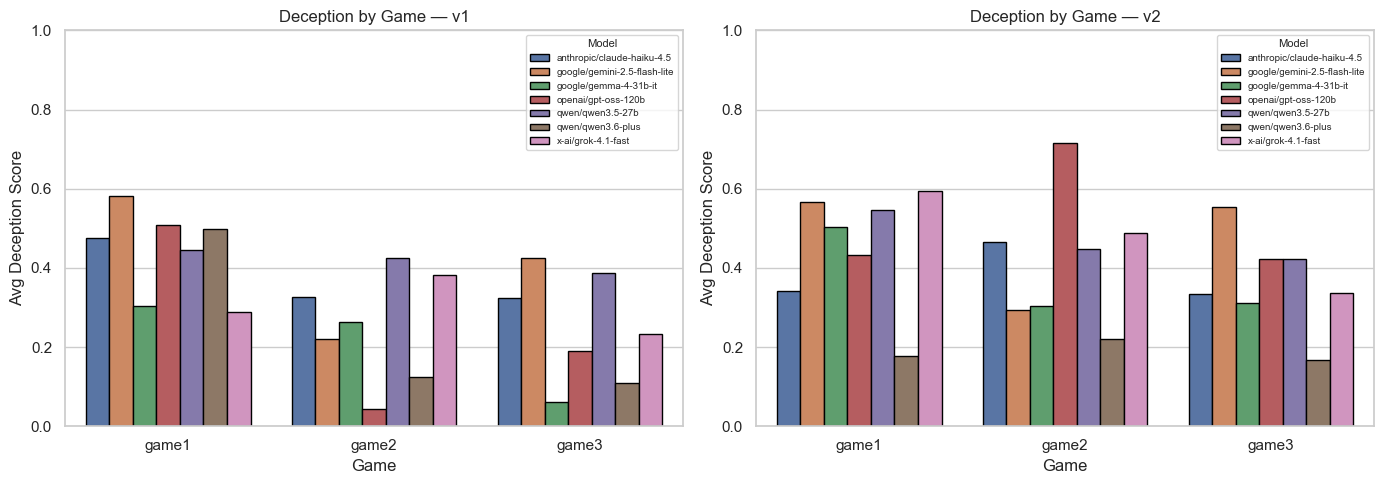


v1 — Average deception by game:
           mean  count
game                  
game1  0.441324    136
game2  0.254815    135
game3  0.233462    130

v2 — Average deception by game:
           mean  count
game                  
game1  0.441154    130
game2  0.418929    140
game3  0.346129    124


In [5]:
if has_any:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for label, dec, exp, ax, color in [
        ("v1", v1_dec, v1, axes[0], "coral"),
        ("v2", v2_dec, v2, axes[1], "steelblue")
    ]:
        if len(dec) == 0:
            ax.set_title(f"{label}: No data")
            continue
        merged = pd.merge(dec, exp['model_df'], on=["game", "power"], how="inner")
        game_model_dec = merged.groupby(["game", "model_name"])["deception_score"].mean().reset_index()

        sns.barplot(data=game_model_dec, x="game", y="deception_score", hue="model_name",
                    ax=ax, edgecolor="black")
        ax.set_xlabel("Game")
        ax.set_ylabel("Avg Deception Score")
        ax.set_title(f"Deception by Game — {label}")
        ax.set_ylim(0, 1)
        ax.legend(title="Model", fontsize=7, title_fontsize=8)

    plt.tight_layout()
    plt.show()

    # Print game-level averages
    for label, dec in [("v1", v1_dec), ("v2", v2_dec)]:
        if len(dec) > 0:
            print(f"\n{label} — Average deception by game:")
            print(dec.groupby("game")["deception_score"].agg(["mean", "count"]).to_string())
else:
    print("No deception data available.")

## 1.5 Does Deception Pay Off? (v1 vs v2)
Does the correlation between deception and game success change when memory works?

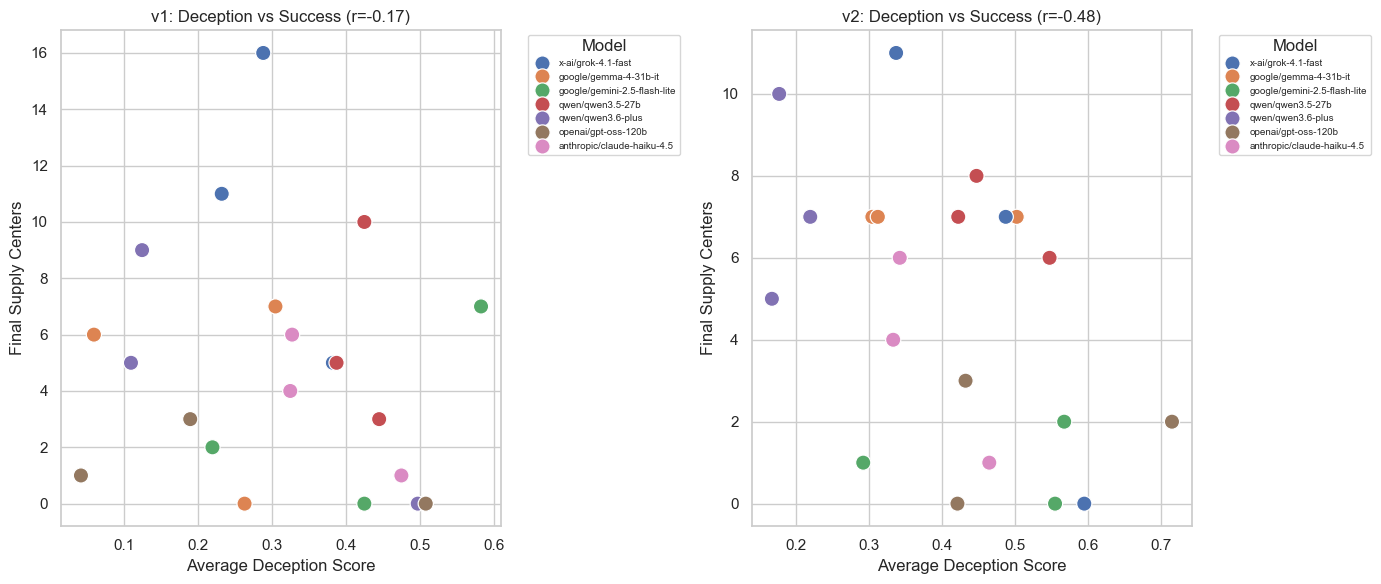

In [6]:
if has_any:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for label, dec, exp, ax, color in [
        ("v1", v1_dec, v1, axes[0], "coral"),
        ("v2", v2_dec, v2, axes[1], "steelblue")
    ]:
        if len(dec) == 0:
            ax.set_title(f"{label}: No data")
            continue
        avg_dec = dec.groupby(["game", "power"])["deception_score"].mean().reset_index()
        avg_dec.rename(columns={"deception_score": "avg_deception"}, inplace=True)
        dec_outcome = pd.merge(avg_dec, exp['sc_df'], on=["game", "power"])
        dec_outcome_model = pd.merge(dec_outcome, exp['model_df'], on=["game", "power"], how="inner")

        sns.scatterplot(data=dec_outcome_model, x="avg_deception", y="final_sc",
                        hue="model_name", s=120, ax=ax)
        corr = dec_outcome_model["avg_deception"].corr(dec_outcome_model["final_sc"])
        ax.set_xlabel("Average Deception Score")
        ax.set_ylabel("Final Supply Centers")
        ax.set_title(f"{label}: Deception vs Success (r={corr:.2f})")
        ax.legend(title="Model", fontsize=7, bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()
    plt.show()
else:
    print("No deception data available.")

## 1.6 Promise Analysis (v1 vs v2)
Does working memory improve promise-keeping? Models that remember who betrayed them may punish broken promises more, incentivizing honesty.

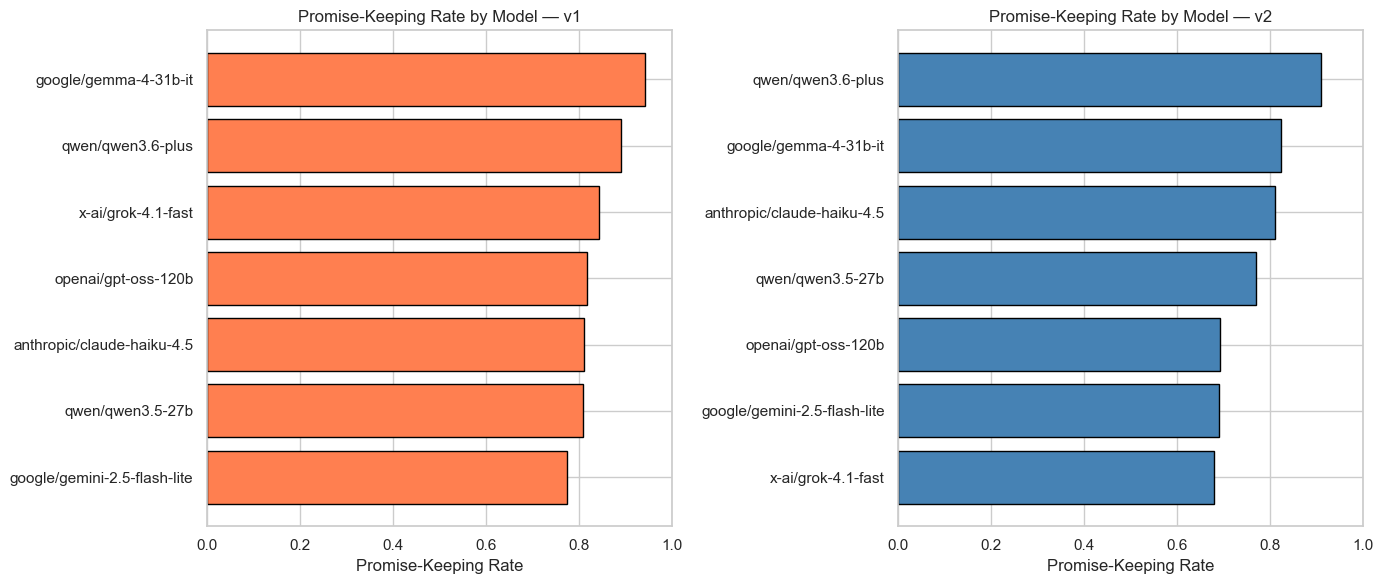


Promise-keeping summary:
  v1: 1409 kept, 273 broken — rate=83.8%
  v2: 1287 kept, 375 broken — rate=77.4%


In [7]:
def safe_json_list(val):
    if pd.isna(val):
        return []
    try:
        result = json.loads(val)
        return result if isinstance(result, list) else []
    except (json.JSONDecodeError, TypeError):
        return []

if has_any:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    promise_summary = []
    for label, dec, exp, ax in [("v1", v1_dec, v1, axes[0]), ("v2", v2_dec, v2, axes[1])]:
        if len(dec) == 0:
            ax.set_title(f"{label}: No data")
            continue
        dec = dec.copy()
        dec["n_broken"] = dec["broken_promises"].apply(safe_json_list).apply(len)
        dec["n_kept"] = dec["kept_promises"].apply(safe_json_list).apply(len)

        merged = pd.merge(dec, exp['model_df'], on=["game", "power"], how="inner")
        by_model = merged.groupby("model_name").agg(
            broken=("n_broken", "sum"), kept=("n_kept", "sum")
        ).reset_index()
        by_model["total"] = by_model["broken"] + by_model["kept"]
        by_model["kept_rate"] = by_model["kept"] / by_model["total"].replace(0, np.nan)
        by_model = by_model.sort_values("kept_rate", ascending=True)

        ax.barh(by_model["model_name"], by_model["kept_rate"].fillna(0),
                color="steelblue" if label == "v2" else "coral", edgecolor="black")
        ax.set_xlabel("Promise-Keeping Rate")
        ax.set_title(f"Promise-Keeping Rate by Model — {label}")
        ax.set_xlim(0, 1)

        total_k = dec["n_kept"].sum()
        total_b = dec["n_broken"].sum()
        rate = total_k / (total_k + total_b) if (total_k + total_b) > 0 else 0
        promise_summary.append({"experiment": label, "kept": total_k, "broken": total_b,
                                "rate": rate})

    plt.tight_layout()
    plt.show()

    if promise_summary:
        print("\nPromise-keeping summary:")
        for p in promise_summary:
            print(f"  {p['experiment']}: {p['kept']} kept, {p['broken']} broken — rate={p['rate']:.1%}")
else:
    print("No deception data available.")

## 1.7 Deception Heatmap (v2 only)
Model vs Year heatmap for the v2 experiment.

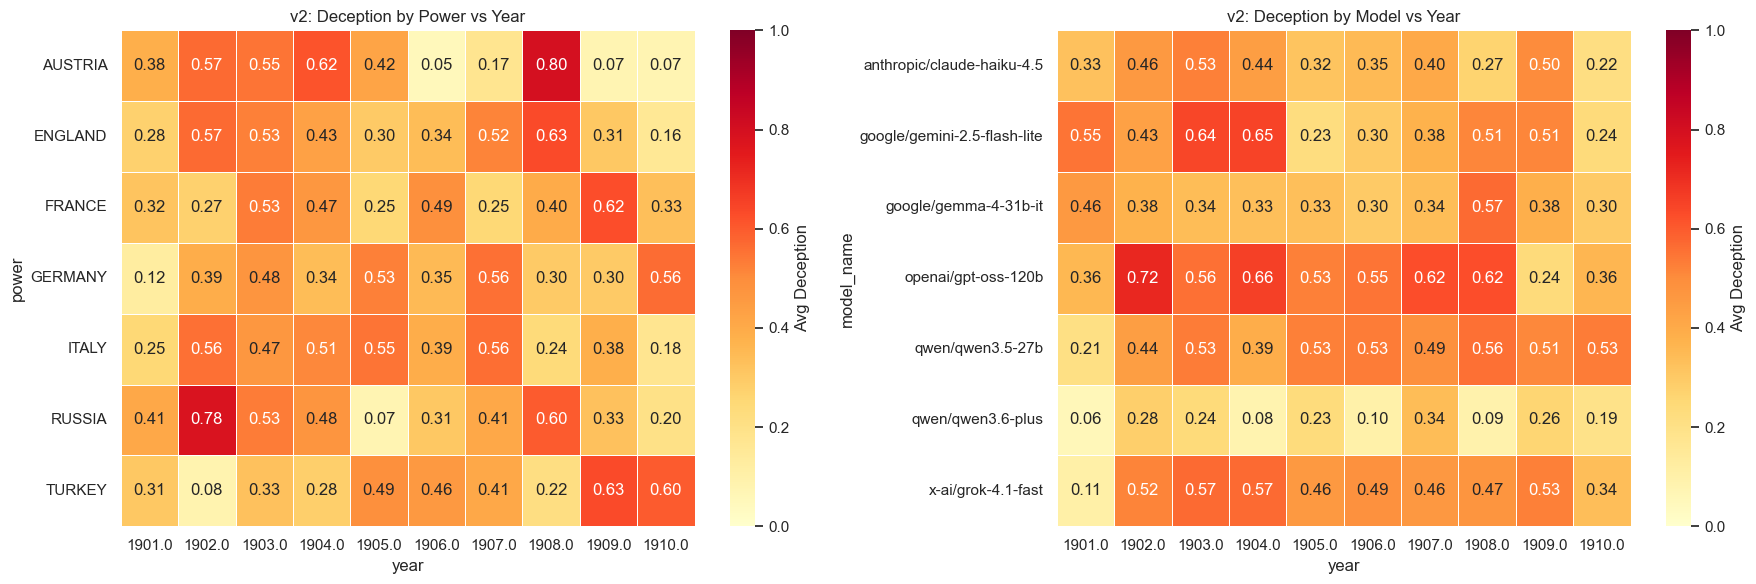

In [8]:
if len(v2_dec) > 0:
    v2_dec_plot = v2_dec.copy()
    v2_dec_plot["year"] = v2_dec_plot["phase"].str.extract(r"(19\d{2})").astype(float)
    merged = pd.merge(v2_dec_plot, v2['model_df'], on=["game", "power"], how="inner")

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # By power
    hm_power = v2_dec_plot.groupby(["power", "year"])["deception_score"].mean().reset_index()
    pivot_power = hm_power.pivot(index="power", columns="year", values="deception_score")
    sns.heatmap(pivot_power, annot=True, cmap="YlOrRd", fmt=".2f", linewidths=0.5,
                cbar_kws={"label": "Avg Deception"}, ax=axes[0], vmin=0, vmax=1)
    axes[0].set_title("v2: Deception by Power vs Year")

    # By model
    hm_model = merged.groupby(["model_name", "year"])["deception_score"].mean().reset_index()
    pivot_model = hm_model.pivot(index="model_name", columns="year", values="deception_score")
    sns.heatmap(pivot_model, annot=True, cmap="YlOrRd", fmt=".2f", linewidths=0.5,
                cbar_kws={"label": "Avg Deception"}, ax=axes[1], vmin=0, vmax=1)
    axes[1].set_title("v2: Deception by Model vs Year")

    plt.tight_layout()
    plt.show()
elif len(v1_dec) > 0:
    print("v2 deception data not yet available. Showing v1 heatmap only.")
    v1_dec_plot = v1_dec.copy()
    v1_dec_plot["year"] = v1_dec_plot["phase"].str.extract(r"(19\d{2})").astype(float)
    merged = pd.merge(v1_dec_plot, v1['model_df'], on=["game", "power"], how="inner")
    hm_model = merged.groupby(["model_name", "year"])["deception_score"].mean().reset_index()
    pivot_model = hm_model.pivot(index="model_name", columns="year", values="deception_score")
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot_model, annot=True, cmap="YlOrRd", fmt=".2f", linewidths=0.5,
                cbar_kws={"label": "Avg Deception"}, vmin=0, vmax=1)
    plt.title("v1: Deception by Model vs Year")
    plt.tight_layout()
    plt.show()
else:
    print("No deception data available.")

---
# Part 2: Error & Reliability Analysis
Operational reliability comparison between v1 and v2. This section works regardless of whether deception scores exist.

## 2.1 Overall Error Rates (v1 vs v2)

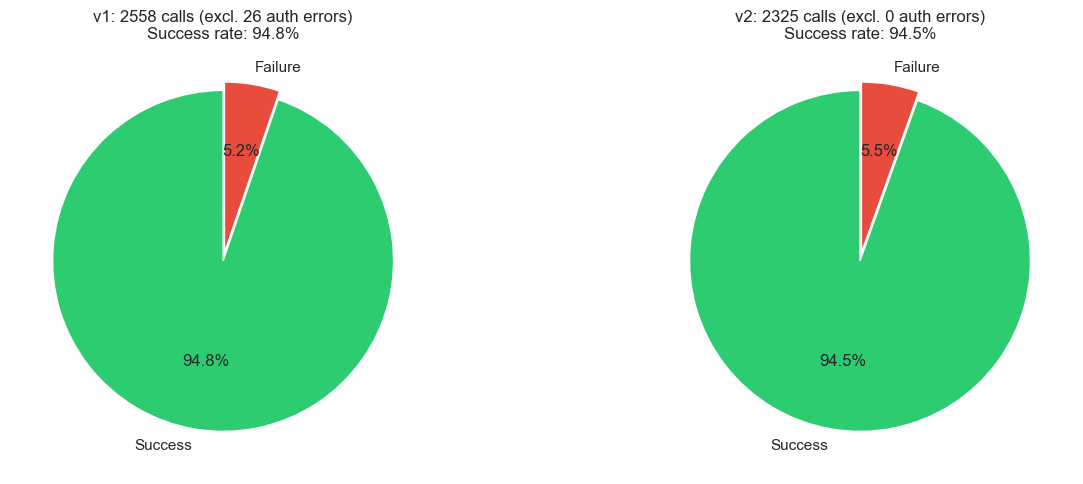

In [9]:
def categorize_success(s):
    s = str(s)
    if s.startswith("Success") or s == "TRUE" or s.startswith("Using prompt"):
        return "Success"
    elif "Invalid LLM Moves" in s:
        return "Invalid Orders"
    elif "No moves extracted" in s:
        return "No Moves Extracted"
    elif "AuthenticationError" in s:
        return "Auth Error"
    elif s.startswith("Failure: Initialized"):
        return "Initialization Failure"
    elif s.startswith("Failure: Exception") or "Exception" in s:
        return "API Exception"
    else:
        return "Other Failure"

for exp in [v1, v2]:
    exp['resp_df']['outcome'] = exp['resp_df']['success'].apply(categorize_success)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (label, exp, color) in enumerate([("v1", v1, "coral"), ("v2", v2, "steelblue")]):
    df = exp['resp_df'][exp['resp_df']['outcome'] != 'Auth Error'].copy()
    n_auth = (exp['resp_df']['outcome'] == 'Auth Error').sum()
    n_success = (df['outcome'] == 'Success').sum()
    n_fail = len(df) - n_success

    axes[i].pie([n_success, n_fail], labels=["Success", "Failure"],
               autopct="%1.1f%%", colors=["#2ecc71", "#e74c3c"],
               startangle=90, explode=(0, 0.05))
    axes[i].set_title(f"{label}: {len(df)} calls (excl. {n_auth} auth errors)\n"
                      f"Success rate: {n_success/len(df):.1%}")

plt.tight_layout()
plt.show()

## 2.2 Model Reliability Comparison (v1 vs v2)

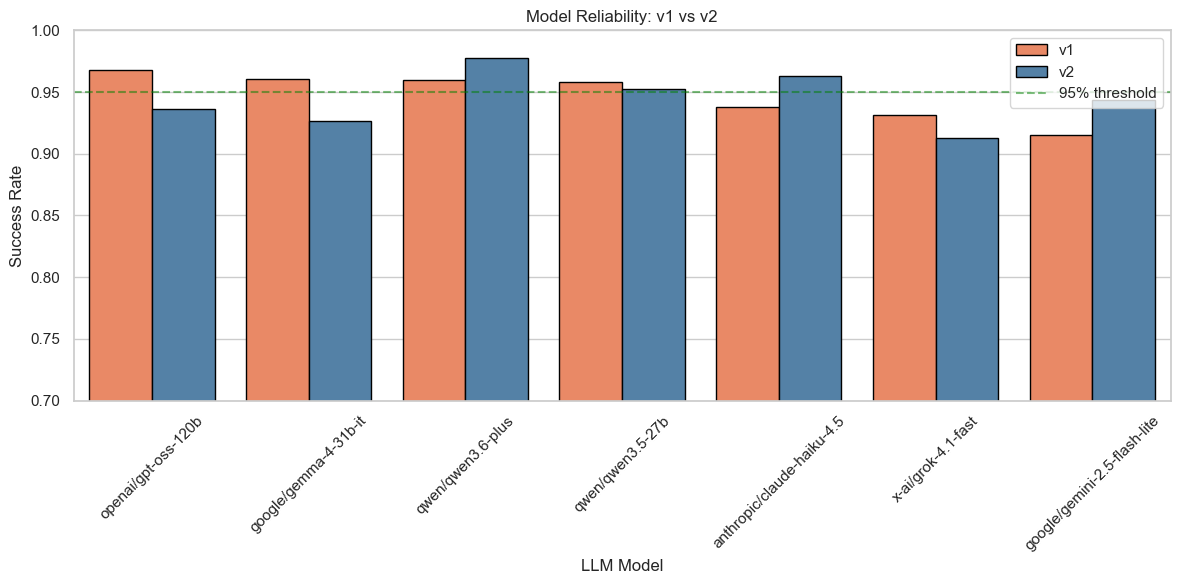


v2 Model Reliability:
                  model_name  total_calls  success_rate  invalid_orders  api_exceptions
           qwen/qwen3.6-plus          355      0.977465               8               0
  anthropic/claude-haiku-4.5          350      0.962857              13               0
            qwen/qwen3.5-27b          355      0.952113              15               0
google/gemini-2.5-flash-lite          300      0.943333              16               0
         openai/gpt-oss-120b          313      0.936102              18               0
       google/gemma-4-31b-it          354      0.926554              24               0
          x-ai/grok-4.1-fast          298      0.912752              26               0


In [10]:
def compute_model_reliability(exp):
    df = exp['resp_df'][exp['resp_df']['outcome'] != 'Auth Error'].copy()
    merged = pd.merge(df, exp['model_df'], on=["game", "power"], how="left")
    stats = merged.groupby("model_name").agg(
        total_calls=("outcome", "count"),
        successes=("outcome", lambda x: (x == "Success").sum()),
        invalid_orders=("outcome", lambda x: (x == "Invalid Orders").sum()),
        api_exceptions=("outcome", lambda x: (x == "API Exception").sum()),
    ).reset_index()
    stats["success_rate"] = stats["successes"] / stats["total_calls"]
    return stats.sort_values("success_rate", ascending=False)

rel_v1 = compute_model_reliability(v1)
rel_v2 = compute_model_reliability(v2)
rel_v1["experiment"] = "v1"
rel_v2["experiment"] = "v2"
rel_combined = pd.concat([rel_v1, rel_v2], ignore_index=True)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=rel_combined, x="model_name", y="success_rate", hue="experiment",
            palette={"v1": "coral", "v2": "steelblue"}, ax=ax, edgecolor="black")
ax.set_xlabel("LLM Model")
ax.set_ylabel("Success Rate")
ax.set_title("Model Reliability: v1 vs v2")
ax.set_ylim(0.7, 1.0)
ax.tick_params(axis="x", rotation=45)
ax.axhline(0.95, color="green", linestyle="--", alpha=0.5, label="95% threshold")
ax.legend()
plt.tight_layout()
plt.show()

print("\nv2 Model Reliability:")
print(rel_v2[["model_name", "total_calls", "success_rate", "invalid_orders", "api_exceptions"]].to_string(index=False))

## 2.3 Invalid Order Rate by Model (v2)

/var/folders/94/c6n86z4n7mzdqsymcrqq9bhr0000gn/T/ipykernel_56813/1913135928.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_order_stats, x="invalid_rate", y="model_name", palette="YlOrRd", edgecolor="black")


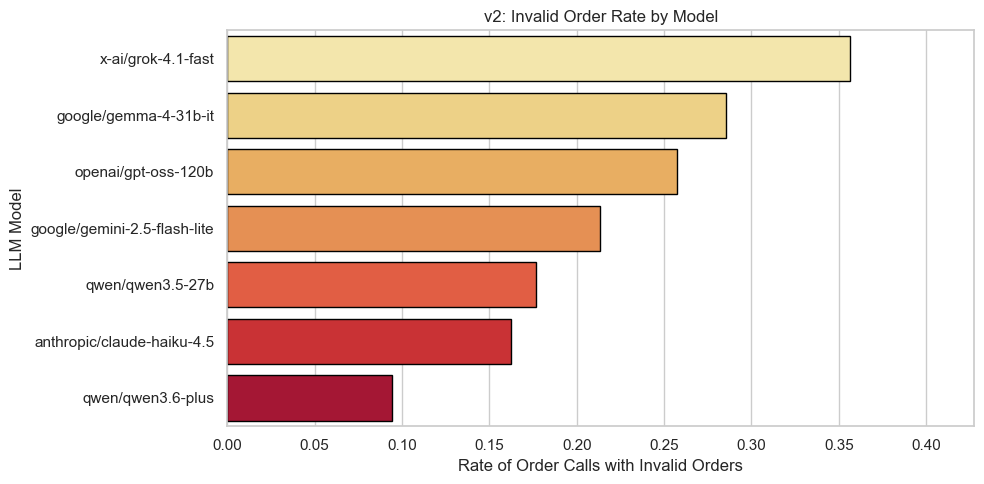

                  model_name  total_calls  invalid_count  total_invalid_orders  invalid_rate
          x-ai/grok-4.1-fast           73             26                    47      0.356164
       google/gemma-4-31b-it           84             24                    33      0.285714
         openai/gpt-oss-120b           70             18                    20      0.257143
google/gemini-2.5-flash-lite           75             16                    22      0.213333
            qwen/qwen3.5-27b           85             15                    19      0.176471
  anthropic/claude-haiku-4.5           80             13                    16      0.162500
           qwen/qwen3.6-plus           85              8                    10      0.094118


In [11]:
def extract_invalid_orders(s):
    s = str(s)
    match = re.search(r"Invalid LLM Moves \((\d+)\): (.+)", s)
    if match:
        return int(match.group(1)), match.group(2)
    return 0, ""

order_df = v2['resp_df'][v2['resp_df']['response_type'] == 'order_generation'].copy()
order_df[["n_invalid", "invalid_orders_str"]] = order_df["success"].apply(
    lambda s: pd.Series(extract_invalid_orders(s)))
order_with_model = pd.merge(order_df, v2['model_df'], on=["game", "power"], how="left")

model_order_stats = order_with_model.groupby("model_name").agg(
    total_calls=("outcome", "count"),
    invalid_count=("n_invalid", lambda x: (x > 0).sum()),
    total_invalid_orders=("n_invalid", "sum")
).reset_index()
model_order_stats["invalid_rate"] = model_order_stats["invalid_count"] / model_order_stats["total_calls"]
model_order_stats = model_order_stats.sort_values("invalid_rate", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=model_order_stats, x="invalid_rate", y="model_name", palette="YlOrRd", edgecolor="black")
plt.xlabel("Rate of Order Calls with Invalid Orders")
plt.ylabel("LLM Model")
plt.title("v2: Invalid Order Rate by Model")
plt.xlim(0, max(model_order_stats["invalid_rate"].max() * 1.2, 0.1))
plt.tight_layout()
plt.show()

print(model_order_stats[["model_name", "total_calls", "invalid_count", "total_invalid_orders", "invalid_rate"]].to_string(index=False))

## 2.4 Error Timeline (v2)

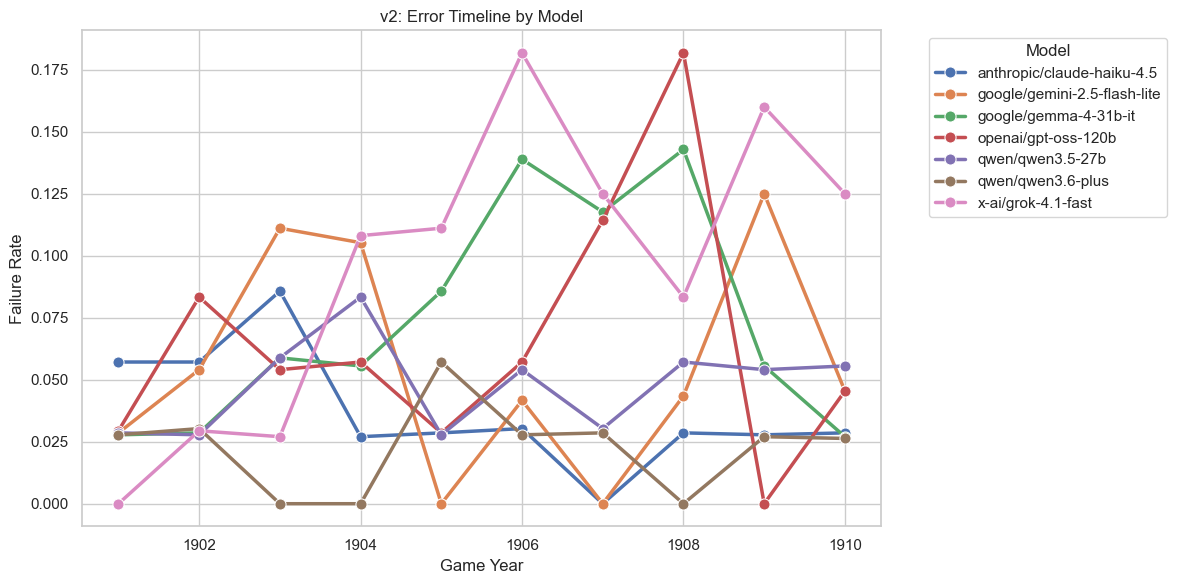

In [12]:
resp_v2_no_auth = v2['resp_df'][v2['resp_df']['outcome'] != 'Auth Error'].copy()
resp_v2_no_auth["year"] = resp_v2_no_auth["phase"].str.extract(r"(19\d{2})").astype(float)
resp_v2_no_auth["is_failure"] = resp_v2_no_auth["outcome"] != "Success"

resp_v2_model = pd.merge(resp_v2_no_auth, v2['model_df'], on=["game", "power"], how="inner")
model_year_err = resp_v2_model.groupby(["model_name", "year"]).agg(
    total=("is_failure", "count"),
    failures=("is_failure", "sum")
).reset_index()
model_year_err["failure_rate"] = model_year_err["failures"] / model_year_err["total"]

plt.figure(figsize=(12, 6))
sns.lineplot(data=model_year_err, x="year", y="failure_rate", hue="model_name",
             marker="o", linewidth=2.5, markersize=8)
plt.xlabel("Game Year")
plt.ylabel("Failure Rate")
plt.title("v2: Error Timeline by Model")
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 2.5 Error Impact on Game Outcomes (v2)

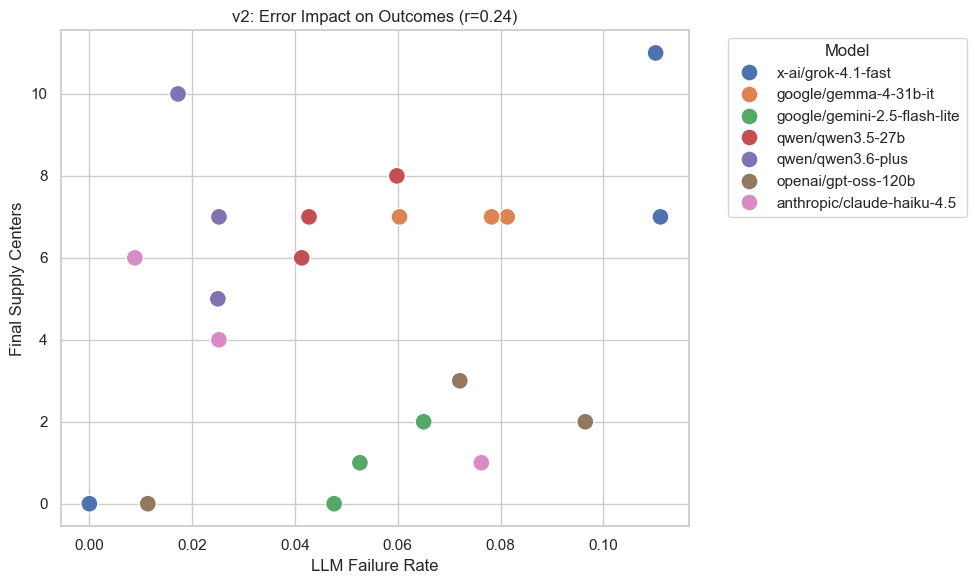

Correlation (failure rate vs SC): r = 0.24


In [13]:
power_errors = resp_v2_no_auth.groupby(["game", "power"]).agg(
    total=("is_failure", "count"),
    failures=("is_failure", "sum")
).reset_index()
power_errors["failure_rate"] = power_errors["failures"] / power_errors["total"]

error_outcome = pd.merge(power_errors, v2['sc_df'], on=["game", "power"])
error_outcome_model = pd.merge(error_outcome, v2['model_df'], on=["game", "power"], how="inner")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=error_outcome_model, x="failure_rate", y="final_sc",
                hue="model_name", s=150)
corr = error_outcome_model["failure_rate"].corr(error_outcome_model["final_sc"])
plt.xlabel("LLM Failure Rate")
plt.ylabel("Final Supply Centers")
plt.title(f"v2: Error Impact on Outcomes (r={corr:.2f})")
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

print(f"Correlation (failure rate vs SC): r = {corr:.2f}")

---
# Part 3: Combined Insights

## 3.1 Reliability vs Deception vs Success (v2)

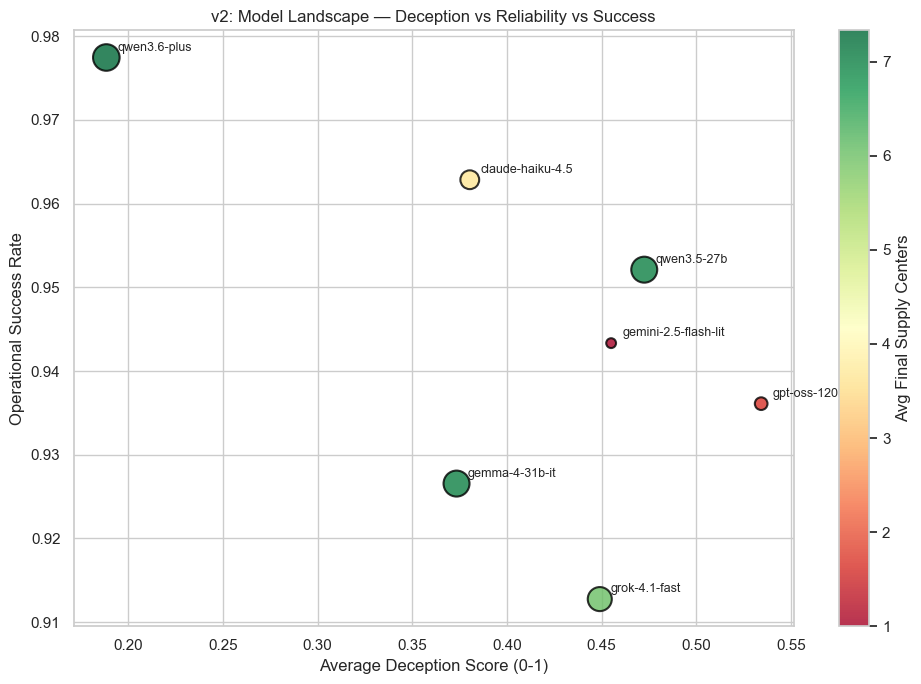

In [14]:
if len(v2_dec) > 0:
    dec_by_model = pd.merge(v2_dec, v2['model_df'], on=["game", "power"], how="inner")
    dec_by_model = dec_by_model.groupby("model_name")["deception_score"].mean().reset_index()
    dec_by_model.rename(columns={"deception_score": "avg_deception"}, inplace=True)

    reliability_slim = rel_v2[["model_name", "success_rate"]].copy()
    sc_with_model = pd.merge(v2['sc_df'], v2['model_df'], on=["game", "power"], how="inner")
    sc_by_model = sc_with_model.groupby("model_name")["final_sc"].mean().reset_index()

    combined = pd.merge(dec_by_model, reliability_slim, on="model_name")
    combined = pd.merge(combined, sc_by_model, on="model_name")

    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(combined["avg_deception"], combined["success_rate"],
                          s=combined["final_sc"] * 50, c=combined["final_sc"],
                          cmap="RdYlGn", edgecolor="black", linewidth=1.5, alpha=0.8)
    plt.colorbar(scatter, label="Avg Final Supply Centers")
    for _, row in combined.iterrows():
        short_name = row["model_name"].split("/")[-1][:20]
        plt.annotate(short_name, (row["avg_deception"], row["success_rate"]),
                     textcoords="offset points", xytext=(8, 5), fontsize=9)
    plt.xlabel("Average Deception Score (0-1)")
    plt.ylabel("Operational Success Rate")
    plt.title("v2: Model Landscape — Deception vs Reliability vs Success")
    plt.tight_layout()
    plt.show()
else:
    print("Deception data not yet available for v2. Run deception_analyzer.py first.")

## 3.2 Key Findings Summary

In [15]:
print("="*60)
print("DECEPTION & ERROR ANALYSIS SUMMARY")
print("="*60)

# Error stats for both
for label, exp in [("v1", v1), ("v2", v2)]:
    df = exp['resp_df'][exp['resp_df']['outcome'] != 'Auth Error']
    n_success = (df['outcome'] == 'Success').sum()
    print(f"\n{label}:")
    print(f"  Total LLM calls (excl auth): {len(df)}")
    print(f"  Success rate: {n_success/len(df):.1%}")
    n_invalid = (df['outcome'] == 'Invalid Orders').sum()
    print(f"  Invalid order calls: {n_invalid} ({n_invalid/len(df):.1%})")

# Deception comparison
if has_both:
    print(f"\n--- Deception Comparison ---")
    print(f"  v1 mean deception: {v1_dec['deception_score'].mean():.3f}")
    print(f"  v2 mean deception: {v2_dec['deception_score'].mean():.3f}")
    delta = v2_dec['deception_score'].mean() - v1_dec['deception_score'].mean()
    direction = "MORE" if delta > 0 else "LESS"
    print(f"  Delta: {delta:+.3f} (models are {direction} deceptive with working memory)")
elif len(v2_dec) > 0:
    print(f"\n--- v2 Deception ---")
    print(f"  Mean: {v2_dec['deception_score'].mean():.3f}")
    print(f"  Median: {v2_dec['deception_score'].median():.3f}")
elif len(v1_dec) > 0:
    print(f"\n--- v1 Deception (v2 not yet available) ---")
    print(f"  Mean: {v1_dec['deception_score'].mean():.3f}")
else:
    print("\nNo deception data available for either experiment.")

print("\n" + "="*60)

DECEPTION & ERROR ANALYSIS SUMMARY

v1:
  Total LLM calls (excl auth): 2558
  Success rate: 94.8%
  Invalid order calls: 107 (4.2%)

v2:
  Total LLM calls (excl auth): 2325
  Success rate: 94.5%
  Invalid order calls: 120 (5.2%)

--- Deception Comparison ---
  v1 mean deception: 0.311
  v2 mean deception: 0.403
  Delta: +0.092 (models are MORE deceptive with working memory)

